<a href="https://colab.research.google.com/github/shohinis/rentsmart/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

housing_df = pd.read_csv('numeric_prop_census_isd.csv')


#changed year built to years since
def years_since(x):
  return 2026-x
yr_built_correct = housing_df['rs_prop_yr_built'].map(years_since)
print(yr_built_correct)
housing_df.insert(1, 'rs_prop_yrs_since_built',yr_built_correct)
housing_df = housing_df.drop(columns=['rs_prop_yr_built'])

#first tried fillna(0) but had bad accuracy-- replaced w mean of columns, didn't change much
for column_name in housing_df:
  housing_df[column_name].fillna(housing_df[column_name].mean(),inplace=True)

print(housing_df.head)


#outcome column: violation_count


0         301
1         301
2         236
3         316
4         227
         ... 
315288      9
315289     22
315290     20
315291     16
315292     25
Name: rs_prop_yr_built, Length: 315293, dtype: int64


/tmp/ipykernel_7368/3550361761.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_df[column_name].fillna(housing_df[column_name].mean(),inplace=True)


<bound method NDFrame.head of         rs_prop_sam_id  rs_prop_yrs_since_built  rs_prop_yr_remod  \
0               407453                      301       2010.000000   
1               407452                      301       2010.000000   
2                62318                      236          0.000000   
3               133181                      316          0.000000   
4                73295                      227       2014.000000   
...                ...                      ...               ...   
315288          186426                        9          0.000000   
315289           80028                       22       1523.764783   
315290           27664                       20       1523.764783   
315291          341536                       16       1523.764783   
315292          106156                       25       1523.764783   

        rs_prop_living_area  json_mhl_housing_5year  \
0                      2160                       0   
1                      2160    

In [4]:
housing_df = housing_df.drop(columns=['json_bldg_mhl_housing_5year','json_mhl_housing_5year','rs_prop_yr_remod'])


In [25]:
#total split: 64% of data to train each classification and regression, 16% to test each, and 20% to test the two-step model
X = housing_df.drop(columns=['violation_count'])
y = housing_df['violation_count']

from sklearn.model_selection import train_test_split
X_train_total, X_test_2step, y_train_total, y_test_2step = train_test_split(X, y, test_size=0.2, random_state=42)



X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_train_total, y_train_total, test_size = 0.2, random_state=42)

#below are the training/testing data to use for classifier since we want to have it train on just 0's and 1's

X_train_cla = X_train_reg.copy()

X_test_cla = X_test_reg.copy()

y_train_cla = y_train_reg.copy()

y_test_cla = y_test_reg.copy()

#TODO drop rows with no violations for regression - get indices from y where violations are not 0 then slice X using those indices
#X_train_reg = X_train_reg[X_train_reg['violat']]
indices_0 = y_train_reg[y_train_reg == 0].index.tolist()
#print("indices 0", indices_0)
#print(y_train_reg)


#TODO: another technique- merge X_train_reg with y_train_reg then drop rows where ytrain is 0, then separate the column for ytrain out again (do the same for ytrain and ytest)
X_train_reg.insert(48, 'violation_count', y_train_reg)
#print("x train reg", X_train_reg.head)
X_train_reg = X_train_reg[X_train_reg['violation_count']>0]
#print("xtrainreg filtered", X_train_reg)
y_train_reg = X_train_reg['violation_count']
X_train_reg = X_train_reg.drop(columns=['violation_count'])

X_test_reg.insert(48, 'violation_count', y_test_reg)
X_test_reg = X_test_reg[X_test_reg['violation_count']>0]
y_test_reg = X_test_reg['violation_count']
X_test_reg = X_test_reg.drop(columns = ['violation_count'])
print("X_test_reg shape", X_test_reg.size)
print("ytest reg shape", y_test_reg.size)

#change classifier data to only 0 or 1
def binary(x):
  if(x==0):
    return 0
  else:
    return 1

y_train_cla = y_train_cla.map(binary)
y_test_cla = y_test_cla.map(binary)



X_train_total.shape, X_test_2step.shape, X_train_reg.shape, X_test_reg.shape

X_test_reg shape 978528
ytest reg shape 20386


((252234, 48), (63059, 48), (80746, 48), (20386, 48))

In [17]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_cla, y_train_cla)
y_pred_cla = log_reg.predict(X_test_cla)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test_cla, y_pred_cla)
cnf_matrix

array([[25395,  4666],
       [13562,  6824]])

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_test_cla, y_pred_cla))

              precision    recall  f1-score   support

           0       0.65      0.84      0.74     30061
           1       0.59      0.33      0.43     20386

    accuracy                           0.64     50447
   macro avg       0.62      0.59      0.58     50447
weighted avg       0.63      0.64      0.61     50447



In [29]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
y_pred_reg_train = lin_reg.predict(X_train_reg)
y_pred_reg = lin_reg.predict(X_test_reg)


In [28]:
c = lin_reg.intercept_
c

m = lin_reg.coef_
m

array([ 2.07657723e-06, -1.08955411e-02,  5.03289038e-06,  2.09067966e+00,
        3.16660293e+03,  3.16660443e+03, -1.47188737e+00,  5.24937463e-04,
        5.45133218e-06,  8.25071740e+00, -8.32489001e-02,  6.82430589e-01,
       -3.62546970e+00,  6.98190618e-01,  1.21373353e-02,  5.72219919e-02,
        2.65923160e-03, -1.62397125e+01,  1.86502390e+01,  1.51256968e+01,
        1.91912764e+01,  6.33322261e+03, -2.86284340e+00,  6.11764769e-05,
       -1.00683103e+00, -9.49983058e+03, -9.49982600e+03, -9.49982826e+03,
       -9.49982384e+03, -9.49982725e+03, -9.49982848e+03,  4.69006203e+01,
        1.93695139e+01,  1.97982698e+01,  1.68973235e-03, -4.70419391e-03,
        1.75737282e-03, -1.27719755e+00, -3.95786657e+00, -2.27864931e+00,
       -2.58648380e-01,  1.44257027e+00, -7.42878767e-01, -1.73107643e-02,
       -2.41959995e-01, -6.68758622e-02, -4.44262234e-02, -1.01335337e-01])

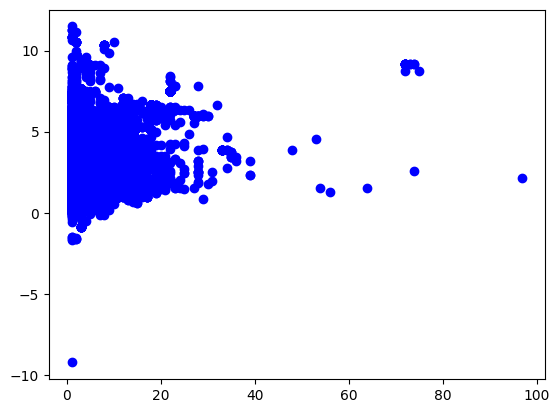

In [30]:
from matplotlib import pyplot as plt
import matplotlib.axes as ax
from IPython.display import clear_output

plt.scatter(y_train_reg, y_pred_reg_train, color='b')
#plt.plot(X_test_reg, y_pred_reg, color = 'k')

plt.show()


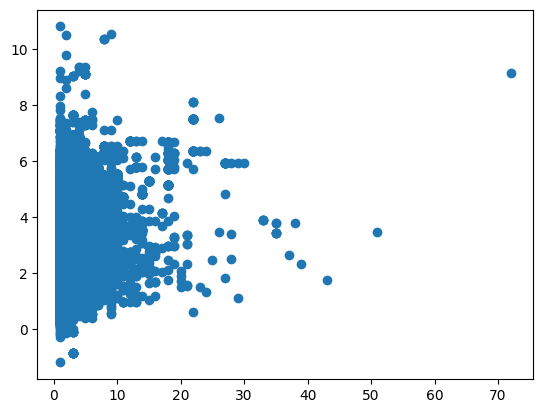

In [31]:
plt.scatter(y_test_reg, y_pred_reg)
plt.show()

In [33]:
from sklearn.metrics import r2_score
r2_score(y_train_reg, y_pred_reg_train)


0.15001257277321567

In [34]:
r2_score(y_test_reg, y_pred_reg)

0.15001257277321567